# 15. Spatio-Temporal GNN Regression Kriging


**Dataset:** California PM2.5 monitoring network, 2025 (`data/CA_pm25_2025.csv`)

**Prediction grid:** Classical space-time Ordinary Kriging reference (`data/CA_pm25_grid_predictions.csv`)

**Target:** Monthly mean PM2.5 (µg/m³)

**Library:** `pygstat` v0.1.0 — `TGCN`, `DCRNN`, `STGNNRegressionKriging`

***



## Table of Contents

1. [Overview](#1-overview)
2. [Mathematical Formulation](#2-mathematical-formulation)
3. [Python Setup](#3-python-setup)
4. [Load and Explore the California PM2.5 Panel](#4-load-and-explore-the-california-pm25-panel)
5. [Spatial $k$-NN Graph](#5-spatial-k-nn-graph)
6. [Hold-Out Station Split](#6-hold-out-station-split)
7. [Fit TGCN and DCRNN](#7-fit-tgcn-and-dcrnn)
8. [Training Curves](#8-training-curves)
9. [Validate on Held-Out Stations](#9-validate-on-held-out-stations)
10. [Residual Variograms](#10-residual-variograms)
11. [Predict on the California Grid](#11-predict-on-the-california-grid)
12. [Compare with Classical ST Kriging](#12-compare-with-classical-st-kriging)
13. [Map Predictions](#13-map-predictions)
14. [CPU vs GPU TGCN Timing](#14-cpu-vs-gpu-tgcn-timing)
15. [Summary and Conclusions](#15-summary-and-conclusions)
16. [Resources](#16-resources)



***
## 1. Overview

**Regression Kriging (RK)** combines a **deterministic trend** with **ordinary kriging of the residuals**. At location $\mathbf{s}$ and time $t$,

$$
Z(\mathbf{s}, t) = \hat{m}(\mathbf{s}, t) + \hat{e}(\mathbf{s}, t)
$$

where $\hat{m}(\mathbf{s}, t)$ is the trend prediction and $\hat{e}(\mathbf{s}, t)$ is the kriged residual. Tutorials 7.1–7.5 use spatial covariates (and, for GNNs, a $k$-NN graph of sample locations) for a *purely spatial* trend. This notebook uses **spatio-temporal graph neural networks** as the trend: nodes are fixed monitoring locations observed repeatedly over time; a GNN combines **spatial** message passing on a $k$-nearest-neighbor graph with a **temporal** GRU-style recurrence, then residuals are kriged independently per month. That is the same RK recipe as [Tutorial 14 (ConvLSTM)](14_kriging_CNNLSTM.ipynb), but with a **graph** backbone instead of a raster/CNN.

This is the deep-learning counterpart of [Tutorial 13 (Spatio-Temporal Kriging)](13_krigingST.ipynb). The validation protocol matches `tests/test_kriging_STGNN.py` exactly (same seed, same 25 held-out stations, same classical ST-kriging grid as the reference surface).

| Step | What we do |
|------|------------|
| Data | Load daily CA PM2.5 for 2025 (163 stations); aggregate to monthly means; project to California Albers (EPSG:3310, meters) |
| Graph | Build a directed $k$-NN graph of stations (`k_neighbors=8`); no self-loops |
| Split | Hold out **25 complete stations** entirely (seed=0), matching `pygstat.krigeST` and the STGNN unit tests |
| Fit | Fit `TGCN` and `DCRNN` (`hidden_dim=32`) on the remaining stations, with per-month residual ordinary kriging |
| Validation | Predict every held-out station-month; report RMSE, MAE, $R^2$ vs a naive-mean baseline |
| Grid | Predict at the 5 km California grid used by classical ST kriging; correlate month-by-month with `CA_pm25_grid_predictions.csv` |
| Mapping | Draw monthly PM2.5 surfaces, kriging standard error, and a side-by-side comparison with the classical reference |
| CPU / GPU | Time `TGCN.fit`+`predict` on CPU vs GPU using **sgsim** CA-like PM2.5 ($n=8{,}400$) |

By the end you will have two validated ST-GNN interpolators, a monthly PM2.5 surface for California in 2025, and a CPU vs GPU timing of TGCN training+inference on an SGS-simulated panel.

### ST-GNN trend models in this notebook

`pygstat` wraps two published recurrent GNN cells. Each follows the same RK recipe: fit the ST-GNN, krige its residuals with `OrdinaryKriging` independently per time step, add the two back together. Graphs are $k$-nearest-neighbor graphs of the coordinates (`scipy.spatial.cKDTree`); aggregation is pure PyTorch (`index_add_`) — no `torch_geometric` dependency.

| Class | Architecture | What the node sees |
|-------|-------------|---------------------|
| `TGCN` | Temporal Graph Convolutional Network (Zhao et al., 2019) | GRU whose gates are 1-hop GraphSAGE-style graph convolutions |
| `DCRNN` | Diffusion Convolutional Recurrent Neural Network (Li et al., 2018) | Same GRU skeleton; each gate is a $K$-hop bidirectional diffusion convolution |
| `STGNNRegressionKriging` | Shared engine | `cell_type='tgcn'` or `'dcrnn'`; `TGCN`/`DCRNN` are thin aliases |

Both are inductive at prediction time: new locations attach only to *training* nodes (never to each other), so a whole grid can be scored in one call with no leakage between query points.



***
## 2. Mathematical Formulation

The target $Z(\mathbf{s}, t)$ at location $\mathbf{s}$ and time $t$ is

$$
Z(\mathbf{s}, t) = \mu(\mathbf{s}, t) + \varepsilon(\mathbf{s}, t)
$$

where $\mu(\mathbf{s}, t)$ is a **deterministic spatio-temporal trend** (the ST-GNN) and $\varepsilon(\mathbf{s}, t)$ is a **zero-mean, spatially autocorrelated residual**, kriged independently at each time step.

### 2.1 Spatial graph

Given $n$ stations with coordinates $\mathbf{s}_i = (x_i, y_i)$, a directed $k$-nearest-neighbor graph $\mathcal{G}=(V,E)$ connects each node to its $k$ nearest *other* stations (self excluded). Edges are stored as `edge_index` of shape $(2, nk)$: row 0 is the neighbor (source), row 1 is the query (destination). At prediction time, each *new* location is attached with $k$ edges **into the training graph only** — no new-to-new edges — so simultaneously scored query points cannot leak information to each other.

Every node's input at time $t$ is the two-channel vector $[m_{i,t}\, z_{i,t},\; m_{i,t}]$, where $m_{i,t}\in\{0,1\}$ is an observation mask. That is IGNNK's masking idea (Wu et al., 2021) in its original space-time setting.

### 2.2 T-GCN cell (Zhao et al., 2019)

A 1-hop graph convolution is GraphSAGE-mean: a node's own features and the mean of its neighbors are transformed separately and summed,

$$
\mathrm{GC}(X) = W_{\mathrm{self}} X + W_{\mathrm{neigh}} D^{-1} A X.
$$

T-GCN replaces every linear map in a GRU with this convolution. With input $X_t$ and previous hidden state $H_{t-1}$,

$$
\begin{aligned}
z_t &= \sigma\big(\mathrm{GC}_z([X_t, H_{t-1}])\big), \\
r_t &= \sigma\big(\mathrm{GC}_r([X_t, H_{t-1}])\big), \\
\tilde H_t &= \tanh\big(\mathrm{GC}_h([X_t, r_t \odot H_{t-1}])\big), \\
H_t &= z_t \odot H_{t-1} + (1-z_t)\odot \tilde H_t.
\end{aligned}
$$

The hidden state at every month is therefore informed by a node's own recent history *and* its neighbors' current state.

### 2.3 DCRNN cell (Li et al., 2018)

DCRNN uses the same GRU skeleton, but each gate is a $K$-hop **bidirectional diffusion convolution**

$$
H = W_0 X + \sum_{k=1}^{K}\big(W_k^f P_f^k X + W_k^b P_b^k X\big),
$$

where $P_f = D^{-1}A$ and $P_b = D^{-1}A^\top$ are the forward and backward row-stochastic random-walk matrices of the $k$-NN graph. Each application of $P$ is a mean-aggregation step (`index_add_` scatter-mean). The extra hop depth and direction-awareness is DCRNN's difference from T-GCN's single-hop, undirected-style aggregation. This notebook uses $K=2$ (`diffusion_k=2`).

A shared linear head maps the top-layer hidden state at each time step to a scalar trend $\hat{m}(\mathbf{s}_i, t)$.

### 2.4 IGNNK-style random masking

Training follows the inductive masked-reconstruction protocol of Wu, Cui, Nie & Wang (2021), shared with `kriging_STGTN` / `kriging_CNNLSTM`. Each epoch:

1. A validation subset of stations is **fully excluded** from the input (they never appear as observed values *or* as reconstruction targets for the training loss).
2. A random fraction `mask_ratio` of the remaining observed (station, month) cells is also hidden.
3. The network reconstructs each hidden station-month from the rest of the space-time graph.

That forces the ST-GNN to interpolate from neighbors and nearby months rather than copy a value it already saw.

### 2.5 Residual kriging

After the network is trained, honest out-of-fold reconstructions (stations left out of the input, then read from the output) yield residuals $e_i(t) = Z(\mathbf{s}_i, t) - \hat{m}(\mathbf{s}_i, t)$. A spherical variogram is fit independently at each month $t$ that has enough observations, and ordinary kriging of those residuals is added back:

$$
\hat{Z}(\mathbf{s}_0, t) = \hat{m}(\mathbf{s}_0, t) + \sum_{i \in \mathcal{O}_t} \lambda_i(t)\, e_i(t).
$$

Set `krige_residuals=False` to skip this step (the prediction is then the ST-GNN trend alone, and `return_std=True` returns zeros).


***
## 3. Python Setup

`TGCN(..., device=...)` (and the other PyTorch ST models) send the network to:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | CUDA when this PyTorch build has kernels for the attached GPU. Falls back to CPU otherwise. |
| `'cuda'` | Force GPU. |
| `'cpu'` | Always CPU. |

This notebook probes CUDA once and stores the result in `DEVICE`. Fits below pass `device=DEVICE`. **§14** times `device='cpu'` against `device='cuda'` on an **SGS-simulated** CA-like PM2.5 panel with $n > 5{,}000$ space-time observations. Residual ordinary kriging is skipped in that section (`krige_residuals=False`) so the times isolate the neural net, not the CPU-only kriging solve.

Install extras with `pip install pygstat[pytorch]`.


In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

# pygstat optionally imports TensorFlow for DeepRegressionKrigingTF.
# Loading that stack in the same process as PyTorch can crash; keep TF out.
sys.modules.setdefault("tensorflow", None)

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from pygstat import DCRNN, STGNNRegressionKriging, TGCN, load_ca_pm25_panel, sgsim
from pygstat.kriging_STGNN import DCRNNCell, TGCNCell, _knn_edges

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:0.3f}")

DATA_DIR = Path("..") / "data"
MONTH_NAMES = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]

print("torch version :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = "cpu"
if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability(0)
    print("GPU           :", torch.cuda.get_device_name(0), f"(sm_{major}{minor})")
    # This wheel ships kernels for sm_75+; older cards fall back to CPU.
    if (major, minor) >= (7, 5):
        DEVICE = "cuda"
    else:
        print("GPU compute capability is below sm_75; using CPU")
print("Using device :", DEVICE)


torch version : 2.14.0+cu126
CUDA available: True
GPU           : NVIDIA GeForce RTX 2080 Ti (sm_75)
Using device : cuda



***
## 4. Load and Explore the California PM2.5 Panel

`data/CA_pm25_2025.csv` holds daily PM2.5 (µg/m³) at 163 California air-quality stations through 2025 (`Site ID`, `Lat`, `Long`, `Date`, `Daily_PM2.5_ug_m3`). `load_ca_pm25_panel` aggregates daily readings to **monthly station means** and projects coordinates from lat/long (EPSG:4326) to **California Albers Equal Area (EPSG:3310, meters)**, so spatial distances in the $k$-NN graph and residual kriging are in a metric unit.

The companion file `data/CA_pm25_grid_predictions.csv` is the classical space-time Ordinary Kriging surface for the same panel (`scripts/predict_ca_pm25_grid.py` via `pygstat.krigeST`) — the reference this tutorial compares against, and the same file used by `tests/test_kriging_STGNN.py`.


In [2]:
raw = pd.read_csv(DATA_DIR / "CA_pm25_2025.csv")
print(f"Daily file : {raw.shape[0]:,} rows, {raw['Site ID'].nunique()} stations")
print(f"Date range : {raw['Date'].min()} -> {raw['Date'].max()}")
print("Columns    :", list(raw.columns))
raw.head()


Daily file : 59,566 rows, 163 stations
Date range : 01/01/2025 -> 12/31/2025
Columns    : ['Site ID', 'State', 'County', 'Lat', 'Long', 'Date', 'Daily_PM2.5_ug_m3', 'Daily_AQI']


,Site ID,State,County,Lat,Long,Date,Daily_PM2.5_ug_m3,Daily_AQI
0,60010009,California,Alameda,37.743,-122.170,01/01/2025,12.200,57
1,60010009,California,Alameda,37.743,-122.170,01/02/2025,9.200,51
2,60010009,California,Alameda,37.743,-122.170,01/03/2025,7.700,43
3,60010009,California,Alameda,37.743,-122.170,01/04/2025,5.800,32
4,60010009,California,Alameda,37.743,-122.170,01/05/2025,6.700,37


In [3]:
panel = load_ca_pm25_panel(DATA_DIR / "CA_pm25_2025.csv")
wide = panel.pivot(index="site_id", columns="month", values="pm25").sort_index()
coords = (
    panel[["site_id", "x", "y"]].drop_duplicates("site_id").set_index("site_id")
    .loc[wide.index][["x", "y"]].to_numpy()
)
values = wide.to_numpy()  # (163, 12); NaN allowed
site_ids = wide.index.to_numpy()
latlon = (
    panel[["site_id", "lat", "lon"]].drop_duplicates("site_id").set_index("site_id")
    .loc[wide.index]
)

n_missing = int(np.isnan(values).sum())
counts = (~np.isnan(values)).sum(axis=1)
complete = np.flatnonzero(counts == 12)

print(f"Monthly panel : {len(panel):,} site-month rows")
print(f"Stations      : {len(coords)}  (coords {coords.shape}, values {values.shape})")
print(f"Complete 12-mo: {len(complete)} / {len(coords)}")
print(f"Missing cells  : {n_missing} station-months (NaN)")
print(
    f"PM2.5 (µg/m³) : mean={np.nanmean(values):.2f}  "
    f"min={np.nanmin(values):.2f}  max={np.nanmax(values):.2f}"
)
print(f"Albers x      : {coords[:, 0].min():.0f} .. {coords[:, 0].max():.0f} m")
print(f"Albers y      : {coords[:, 1].min():.0f} .. {coords[:, 1].max():.0f} m")
panel.head()


Monthly panel : 1,935 site-month rows
Stations      : 163  (coords (163, 2), values (163, 12))
Complete 12-mo: 156 / 163
Missing cells  : 21 station-months (NaN)
PM2.5 (µg/m³) : mean=7.01  min=-0.50  max=39.05
Albers x      : -352817 .. 424125 m
Albers y      : -602223 .. 423150 m


,site_id,month,pm25,lat,lon,x,y
0,60010009,0,6.948,37.743,-122.170,-190936.009,-28196.821
1,60010009,1,3.736,37.743,-122.170,-190936.009,-28196.821
2,60010009,2,3.681,37.743,-122.170,-190936.009,-28196.821
3,60010009,3,5.323,37.743,-122.170,-190936.009,-28196.821
4,60010009,4,6.922,37.743,-122.170,-190936.009,-28196.821


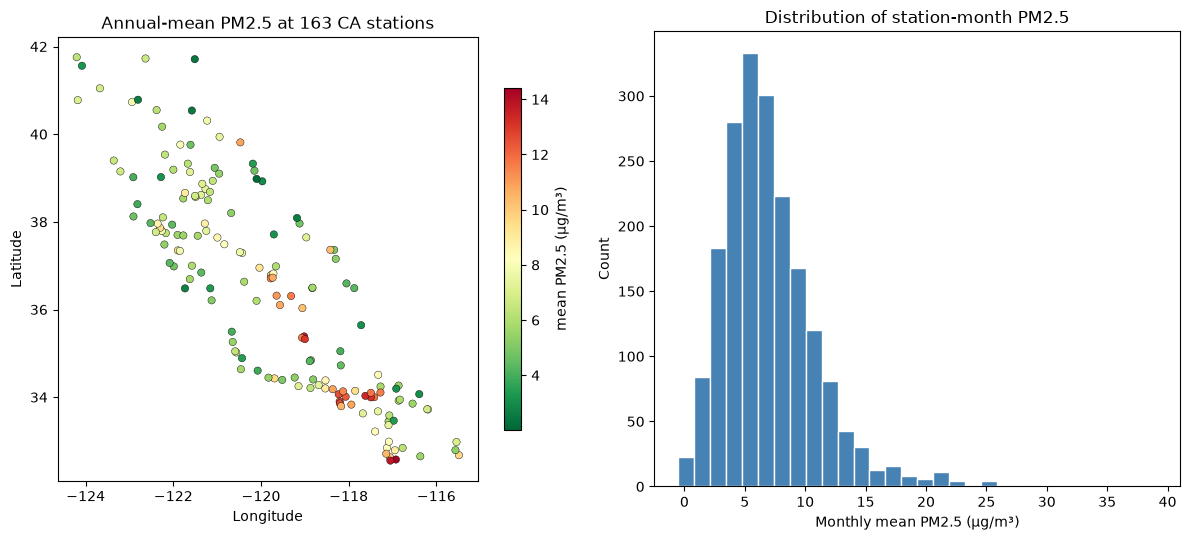

In [4]:
mean_pm = np.nanmean(values, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

sc = axes[0].scatter(
    latlon["lon"], latlon["lat"], c=mean_pm,
    cmap="RdYlGn_r", s=28, edgecolor="k", linewidth=0.3,
)
plt.colorbar(sc, ax=axes[0], label="mean PM2.5 (µg/m³)", shrink=0.75)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Annual-mean PM2.5 at 163 CA stations")
axes[0].set_aspect("equal", adjustable="box")

axes[1].hist(values[~np.isnan(values)], bins=30, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Monthly mean PM2.5 (µg/m³)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of station-month PM2.5")
plt.tight_layout()
plt.show()


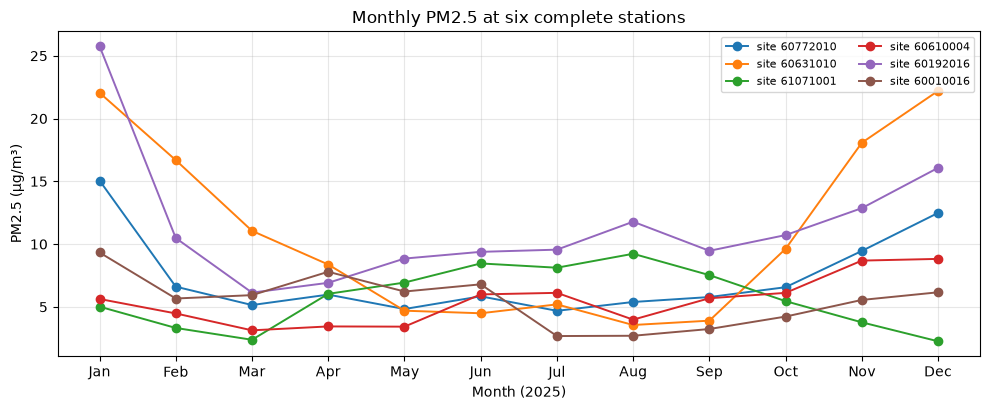

In [5]:
# Six example station series (shared winter peak, station-to-station amplitude)
rng_plot = np.random.default_rng(1)
demo_idx = rng_plot.choice(complete, size=6, replace=False)

fig, ax = plt.subplots(figsize=(10, 4.2))
for i in demo_idx:
    ax.plot(range(12), values[i], marker="o", linewidth=1.4, label=f"site {int(site_ids[i])}")
ax.set_xticks(range(12), MONTH_NAMES)
ax.set_xlabel("Month (2025)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.set_title("Monthly PM2.5 at six complete stations")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



Annual-mean PM2.5 is highest in the Central Valley and the South Coast and lowest along the north coast and Sierra. The six example series show a shared seasonal pattern (higher in winter) plus station-to-station differences — the two ingredients a spatial graph plus a temporal recurrence have to capture.



***
## 5. Spatial $k$-NN Graph

Before fitting, look at the graph the ST-GNN actually sees. `_knn_edges` builds each station's 8 nearest other stations (no self-loops). Dense clusters (South Coast, Central Valley) have short edges; isolated desert and north-coast sites reach farther. At prediction time the same constructor attaches *query* points to training nodes only — that is the inductive extension the unit tests check.


Training graph : 163 nodes, 1304 directed edges
edge_index     : (2, 1304)  (expected (2, 1304))
Self-loops     : False
Edge length    : median=44.8 km, max=224.5 km
Query edges    : sources all in training (True), destinations all query (True)


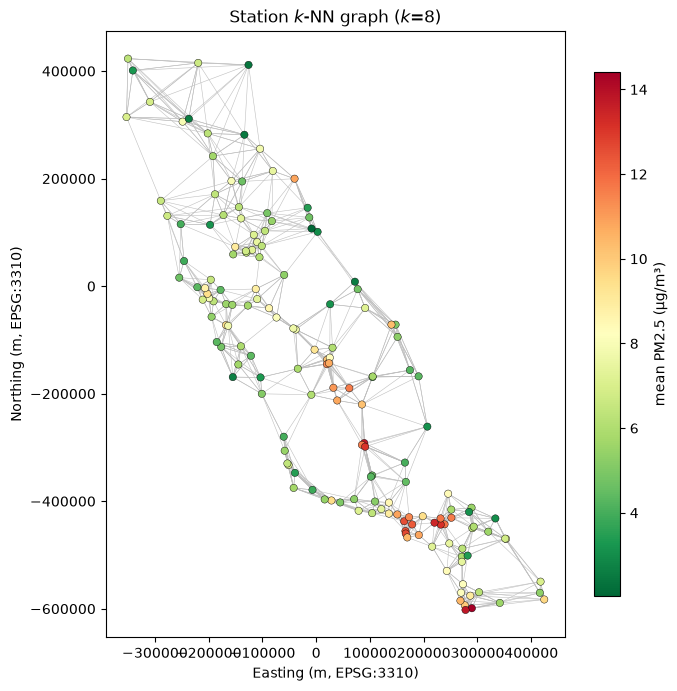

In [6]:
K_NEIGHBORS = 8
edge_index, edge_dist = _knn_edges(coords, k=K_NEIGHBORS)
src, dst = edge_index.numpy()
print(f"Training graph : {len(coords)} nodes, {edge_index.shape[1]} directed edges")
print(f"edge_index     : {tuple(edge_index.shape)}  (expected (2, {len(coords) * K_NEIGHBORS}))")
print(f"Self-loops     : {(src == dst).any()}")
print(f"Edge length    : median={np.median(edge_dist)/1000:.1f} km, "
      f"max={edge_dist.max()/1000:.1f} km")

# Inductive extension: query nodes only receive edges from training nodes
rng_q = np.random.default_rng(1)
query = rng_q.uniform(coords.min(0), coords.max(0), size=(6, 2))
q_edge, _ = _knn_edges(coords, k=4, query_coords=query)
q_src, q_dst = q_edge.numpy()
print(f"Query edges    : sources all in training ({(q_src < len(coords)).all()}), "
      f"destinations all query ({(q_dst >= len(coords)).all()})")

fig, ax = plt.subplots(figsize=(7, 8))
ax.plot(
    np.vstack([coords[src, 0], coords[dst, 0]]),
    np.vstack([coords[src, 1], coords[dst, 1]]),
    color="0.75", linewidth=0.4, zorder=1,
)
sc = ax.scatter(
    coords[:, 0], coords[:, 1], c=np.nanmean(values, axis=1),
    cmap="RdYlGn_r", s=28, edgecolor="k", linewidth=0.3, zorder=2,
)
plt.colorbar(sc, ax=ax, shrink=0.7, label="mean PM2.5 (µg/m³)")
ax.set_xlabel("Easting (m, EPSG:3310)")
ax.set_ylabel("Northing (m, EPSG:3310)")
ax.set_title(f"Station $k$-NN graph ($k$={K_NEIGHBORS})")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


In [7]:
# One recurrent step: 2-D input [masked value, mask] -> hidden state
n_demo = 8
demo_xy = coords[:n_demo]
e_idx, _ = _knn_edges(demo_xy, k=3)
e_rev = e_idx.flip(0)
x = torch.randn(n_demo, 2)
h0 = torch.zeros(n_demo, 5)

h_tgcn = TGCNCell(in_dim=2, hidden_dim=5)(x, h0, e_idx, n_nodes=n_demo)
h_dcrnn = DCRNNCell(in_dim=2, hidden_dim=5, k_hops=2)(x, h0, e_idx, e_rev, n_nodes=n_demo)
print(f"TGCNCell  hidden : {tuple(h_tgcn.shape)}, finite={bool(torch.isfinite(h_tgcn).all())}")
print(f"DCRNNCell hidden : {tuple(h_dcrnn.shape)}, finite={bool(torch.isfinite(h_dcrnn).all())}")
print(f"STGNNRegressionKriging aliases: TGCN is subclass={issubclass(TGCN, STGNNRegressionKriging)}, "
      f"DCRNN is subclass={issubclass(DCRNN, STGNNRegressionKriging)}")


TGCNCell  hidden : (8, 5), finite=True
DCRNNCell hidden : (8, 5), finite=True
STGNNRegressionKriging aliases: TGCN is subclass=True, DCRNN is subclass=True



***
## 6. Hold-Out Station Split

To test genuine spatial-temporal *extrapolation* (not just interpolating a missing month at a known site), we hold out **25 stations with complete 12-month coverage** entirely. Every month at those sites is predicted from the remaining 138 stations. The 7 stations with partial-year coverage stay in the training set: `TGCN.fit` / `DCRNN.fit` already allow NaN. This split (seed=0, `n_test=25`) is the same protocol as `pygstat.krigeST` and `tests/test_kriging_STGNN.py`.


Train : 138 stations, 1635 site-months
Test  : 25 stations (held out), 300 site-months


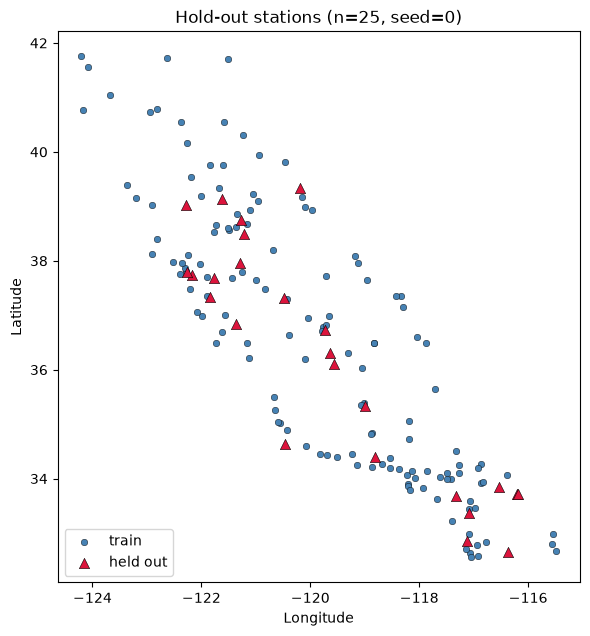

In [8]:
rng = np.random.default_rng(0)
test_idx = rng.choice(complete, size=25, replace=False)
train_mask = np.ones(len(values), dtype=bool)
train_mask[test_idx] = False

coords_train, values_train = coords[train_mask], values[train_mask]
coords_test, values_test = coords[test_idx], values[test_idx]
latlon_train = latlon.iloc[np.flatnonzero(train_mask)]
latlon_test = latlon.iloc[test_idx]

print(f"Train : {train_mask.sum()} stations, {int(np.isfinite(values_train).sum())} site-months")
print(f"Test  : {len(test_idx)} stations (held out), {int(np.isfinite(values_test).sum())} site-months")

fig, ax = plt.subplots(figsize=(6, 7))
ax.scatter(
    latlon_train["lon"], latlon_train["lat"],
    s=22, c="steelblue", edgecolor="k", linewidth=0.3, label="train",
)
ax.scatter(
    latlon_test["lon"], latlon_test["lat"],
    s=55, c="crimson", marker="^", edgecolor="k", linewidth=0.4, label="held out",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Hold-out stations (n=25, seed=0)")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()



***
## 7. Fit TGCN and DCRNN

Both families are fit on the **training stations only**. Hyperparameters match `tests/test_kriging_STGNN.py`: `k_neighbors=8`, `hidden_dim=32`, `max_epochs=300`, `patience=30`. A random 15% of training stations are held out internally for early stopping (`val_fraction=0.15`). Residual ordinary kriging uses a spherical variogram, independently per month.

`seed=` controls the (station, time) masking pattern, not PyTorch's global weight-init RNG, so exact numbers vary a little run to run — the same caveat as ConvLSTM and the graph-Transformer sibling modules.


In [9]:
COMMON = dict(
    k_neighbors=8,
    hidden_dim=32,
    max_epochs=300,
    patience=30,
    device=DEVICE,
    seed=0,
)

specs = {
    "tgcn": TGCN,
    "dcrnn": DCRNN,
}

fitted = {}
for name, cls in specs.items():
    print()
    print(f"===== {name.upper()} =====")
    rk = cls(**COMMON)
    rk.fit(coords_train, values_train, verbose=True)
    fitted[name] = rk
    print()
    print(rk)
    print(f"Epochs run     : {len(rk.train_losses_)}")
    print(f"Best val loss  : {min(rk.val_losses_):.6f}")
    print(f"Months with OK : {sorted(rk.krige_by_step_)}")



===== TGCN =====


Epoch 1/300 - Train Loss: 0.972487, Val Loss: 0.910202
Epoch 2/300 - Train Loss: 1.158908, Val Loss: 0.909460
Epoch 3/300 - Train Loss: 1.157714, Val Loss: 0.909750
Epoch 4/300 - Train Loss: 0.768148, Val Loss: 0.910069
Epoch 5/300 - Train Loss: 1.159013, Val Loss: 0.910590
Epoch 6/300 - Train Loss: 1.122171, Val Loss: 0.911786


Epoch 7/300 - Train Loss: 0.935300, Val Loss: 0.912395
Epoch 8/300 - Train Loss: 1.030395, Val Loss: 0.912907
Epoch 9/300 - Train Loss: 0.898527, Val Loss: 0.911985
Epoch 10/300 - Train Loss: 1.115451, Val Loss: 0.910809
Epoch 11/300 - Train Loss: 0.924023, Val Loss: 0.909982


Epoch 12/300 - Train Loss: 1.057872, Val Loss: 0.909361
Epoch 13/300 - Train Loss: 1.174683, Val Loss: 0.909001
Epoch 14/300 - Train Loss: 1.072420, Val Loss: 0.907488
Epoch 15/300 - Train Loss: 0.838329, Val Loss: 0.904845
Epoch 16/300 - Train Loss: 1.116970, Val Loss: 0.903112
Epoch 17/300 - Train Loss: 1.049922, Val Loss: 0.900917


Epoch 18/300 - Train Loss: 0.980702, Val Loss: 0.897418
Epoch 19/300 - Train Loss: 0.912074, Val Loss: 0.892813
Epoch 20/300 - Train Loss: 1.073858, Val Loss: 0.888480
Epoch 21/300 - Train Loss: 0.937633, Val Loss: 0.883401
Epoch 22/300 - Train Loss: 0.948203, Val Loss: 0.878729
Epoch 23/300 - Train Loss: 1.031124, Val Loss: 0.872974


...

Epoch 99/300 - Train Loss: 0.374692, Val Loss: 0.567053
Epoch 100/300 - Train Loss: 0.528451, Val Loss: 0.573295


Epoch 101/300 - Train Loss: 0.384543, Val Loss: 0.579236
Epoch 102/300 - Train Loss: 0.489119, Val Loss: 0.583604


Epoch 103/300 - Train Loss: 0.482158, Val Loss: 0.585889
Epoch 104/300 - Train Loss: 0.551644, Val Loss: 0.588250


Epoch 105/300 - Train Loss: 0.476150, Val Loss: 0.589957
Epoch 106/300 - Train Loss: 0.500539, Val Loss: 0.594203



DCRNN(cell_type='dcrnn', k_neighbors=8, fitted)
Epochs run     : 107
Best val loss  : 0.458607
Months with OK : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]



***
## 8. Training Curves

Validation loss is the early-stopping signal: a held-out fraction of *training* stations is fully excluded from the graph input at every epoch, so the curve measures reconstruction at locations the ST-GNN never saw as observed values.


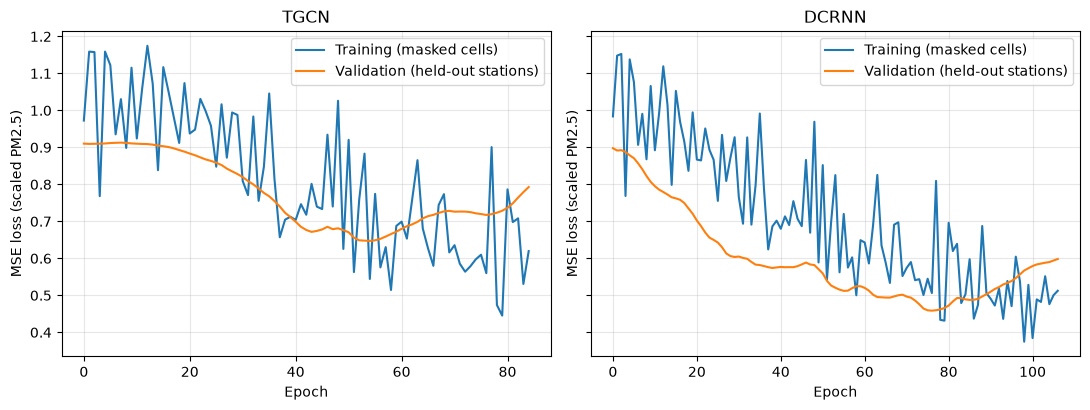

In [10]:
n = len(fitted)
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 4.2), sharey=True)
if n == 1:
    axes = [axes]
for ax, (name, rk) in zip(axes, fitted.items()):
    ax.plot(rk.train_losses_, label="Training (masked cells)")
    ax.plot(rk.val_losses_, label="Validation (held-out stations)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE loss (scaled PM2.5)")
    ax.set_title(name.upper())
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



***
## 9. Validate on Held-Out Stations

Predict every station-month of the 25 held-out stations from each trained ST-GNN + residual kriging, and compare against a **naive baseline**: the overall training-mean PM2.5, which uses no spatial or temporal information. Classical space-time Ordinary Kriging on this exact split scores RMSE ≈ 2.24 µg/m³ ($R^2$ ≈ 0.58). Development runs of this test had TGCN at RMSE ≈ 2.03 ($R^2$ ≈ 0.66, *better* than classical ST kriging) and DCRNN at ≈ 2.34 ($R^2$ ≈ 0.54). Exact numbers move a little because weight initialization is not pinned.


In [11]:
train_mean = float(np.nanmean(values_train))
obs_mask_test = ~np.isnan(values_test)
y_obs = values_test[obs_mask_test]
baseline_rmse = float(np.sqrt(mean_squared_error(y_obs, np.full_like(y_obs, train_mean))))

rows = []
pred_lookup = {}
for name, rk in fitted.items():
    y_hat_full, y_std_full = rk.predict(coords_test, return_std=True)
    y_hat = y_hat_full[obs_mask_test]
    pred_lookup[name] = {"y_pred": y_hat_full, "y_std": y_std_full}
    rmse = float(np.sqrt(mean_squared_error(y_obs, y_hat)))
    rows.append({
        "family": name,
        "class": type(rk).__name__,
        "k_neighbors": rk.k_neighbors,
        "hidden_dim": rk.hidden_dim,
        "epochs": len(rk.train_losses_),
        "test_rmse": rmse,
        "test_mae": float(mean_absolute_error(y_obs, y_hat)),
        "test_r2": float(r2_score(y_obs, y_hat)),
        "test_me": float((y_obs - y_hat).mean()),
        "rmse_vs_baseline": rmse / baseline_rmse,
        "mean_se": float(y_std_full[obs_mask_test].mean()),
    })

results = pd.DataFrame(rows).set_index("family")
print(f"Naive-mean baseline RMSE = {baseline_rmse:.3f} µg/m³")
display(results.round(3))
best_name = results["test_rmse"].idxmin()
print(f"Best held-out family: {best_name}  (RMSE={results.loc[best_name, 'test_rmse']:.3f})")


Naive-mean baseline RMSE = 3.461 µg/m³


,class,k_neighbors,hidden_dim,epochs,test_rmse,test_mae,test_r2,test_me,rmse_vs_baseline,mean_se
family,,,,,,,,,,
tgcn,TGCN,8,32,85,2.073,1.629,0.639,0.380,0.599,2.579
dcrnn,DCRNN,8,32,107,2.245,1.698,0.576,0.179,0.649,2.663


Best held-out family: tgcn  (RMSE=2.073)


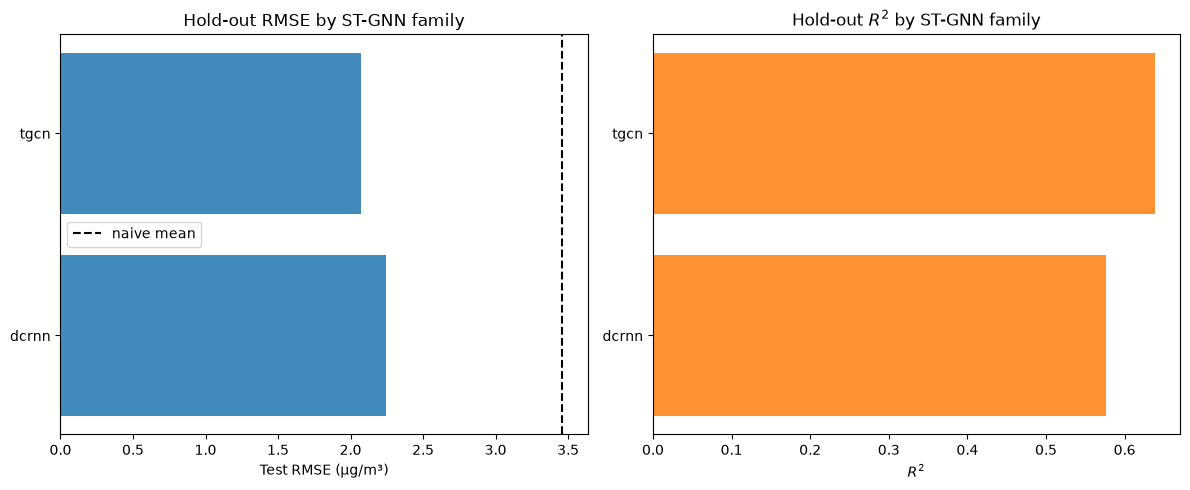

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = results.sort_values("test_rmse")
axes[0].barh(order.index, order["test_rmse"], color="C0", alpha=0.85)
axes[0].axvline(baseline_rmse, color="k", linestyle="--", label="naive mean")
axes[0].set_xlabel("Test RMSE (µg/m³)")
axes[0].set_title("Hold-out RMSE by ST-GNN family")
axes[0].invert_yaxis()
axes[0].legend()

axes[1].barh(order.index, order["test_r2"], color="C1", alpha=0.85)
axes[1].set_xlabel("$R^2$")
axes[1].set_title("Hold-out $R^2$ by ST-GNN family")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


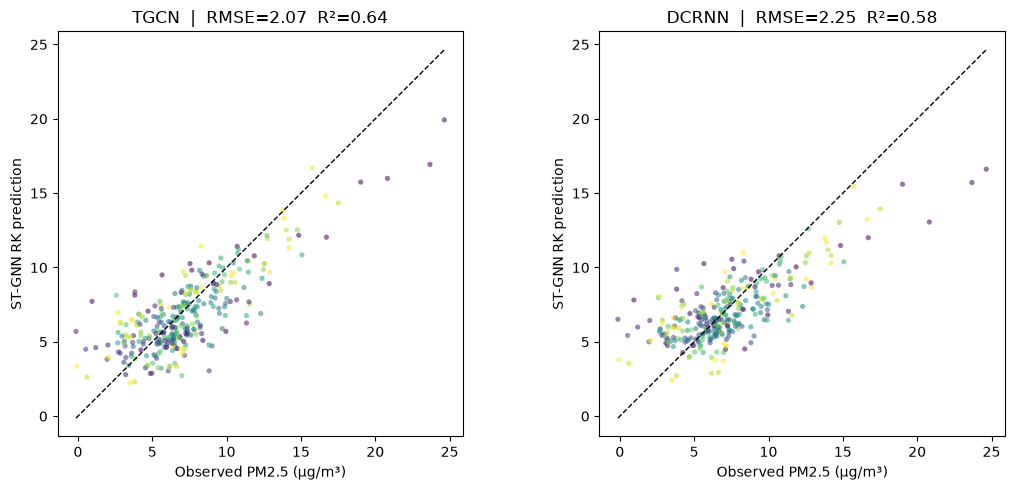

In [13]:
show = list(fitted)
fig, axes = plt.subplots(1, len(show), figsize=(5.5 * len(show), 5.0))
if len(show) == 1:
    axes = [axes]
lims = [
    min(y_obs.min(), min(pred_lookup[n]["y_pred"][obs_mask_test].min() for n in show)),
    max(y_obs.max(), max(pred_lookup[n]["y_pred"][obs_mask_test].max() for n in show)),
]
month_of = np.where(obs_mask_test)[1]
for ax, name in zip(axes, show):
    y_hat = pred_lookup[name]["y_pred"][obs_mask_test]
    rmse = results.loc[name, "test_rmse"]
    r2 = results.loc[name, "test_r2"]
    ax.scatter(y_obs, y_hat, s=14, alpha=0.55, c=month_of, cmap="viridis", edgecolor="none")
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlabel("Observed PM2.5 (µg/m³)")
    ax.set_ylabel("ST-GNN RK prediction")
    ax.set_title(f"{name.upper()}  |  RMSE={rmse:.2f}  R²={r2:.2f}")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


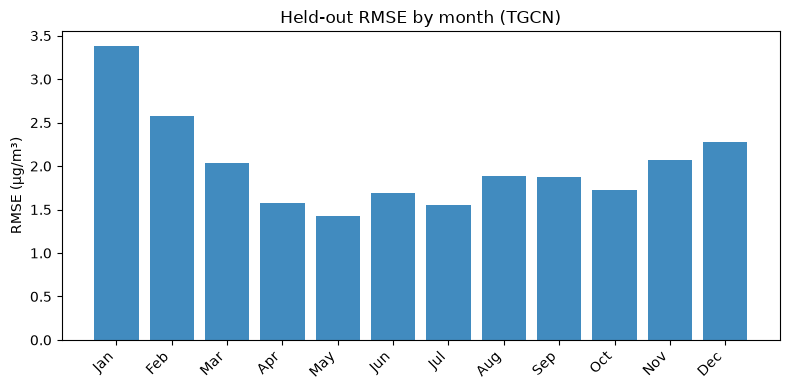

In [14]:
# RMSE by month for the best family
best_pred = pred_lookup[best_name]["y_pred"]
rmse_by_month = []
for m in range(12):
    m_obs = values_test[:, m]
    m_hat = best_pred[:, m]
    keep = ~np.isnan(m_obs)
    rmse_by_month.append(float(np.sqrt(np.mean((m_obs[keep] - m_hat[keep]) ** 2))))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(12), rmse_by_month, color="C0", alpha=0.85)
ax.set_xticks(range(12), MONTH_NAMES, rotation=45, ha="right")
ax.set_ylabel("RMSE (µg/m³)")
ax.set_title(f"Held-out RMSE by month ({best_name.upper()})")
plt.tight_layout()
plt.show()


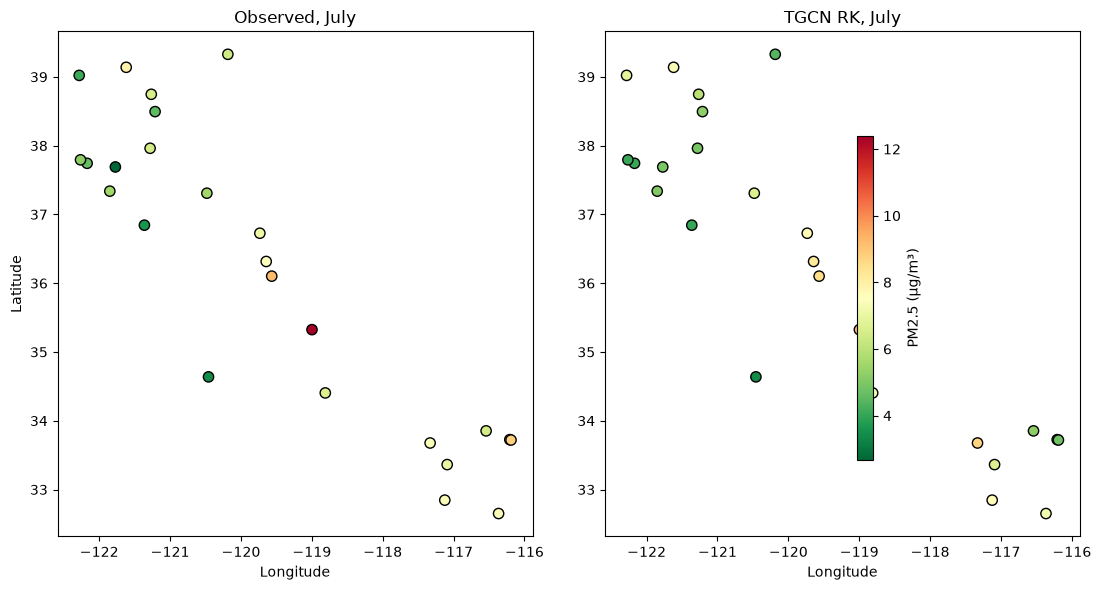

In [15]:
# July snapshot at the 25 held-out stations
snap_m = 6
vmin = np.nanmin([values_test[:, snap_m].min(), best_pred[:, snap_m].min()])
vmax = np.nanmax([values_test[:, snap_m].max(), best_pred[:, snap_m].max()])
fig, axj = plt.subplots(1, 2, figsize=(11, 6))
s0 = axj[0].scatter(
    latlon_test["lon"], latlon_test["lat"], c=values_test[:, snap_m],
    vmin=vmin, vmax=vmax, cmap="RdYlGn_r", s=55, edgecolor="k",
)
axj[0].set_title("Observed, July")
axj[0].set_xlabel("Longitude")
axj[0].set_ylabel("Latitude")
s1 = axj[1].scatter(
    latlon_test["lon"], latlon_test["lat"], c=best_pred[:, snap_m],
    vmin=vmin, vmax=vmax, cmap="RdYlGn_r", s=55, edgecolor="k",
)
axj[1].set_title(f"{best_name.upper()} RK, July")
axj[1].set_xlabel("Longitude")
plt.colorbar(s1, ax=axj, label="PM2.5 (µg/m³)", shrink=0.7)
plt.tight_layout()
plt.show()



If RMSE is well below the naive-mean baseline, the graph recurrence (plus residual kriging) is doing real work: nearby stations and nearby months are informing the prediction. Residual RMSE that varies by month usually tracks the seasonal amplitude of PM2.5 (winter is harder).



***
## 10. Residual Variograms

A spherical variogram is fit independently at each month on each model's out-of-fold residuals. A better neighborhood-aware trend typically leaves **less structured** residual spatial variation (smaller sill / shorter range). January (peak winter PM2.5) and July are shown for the best family.


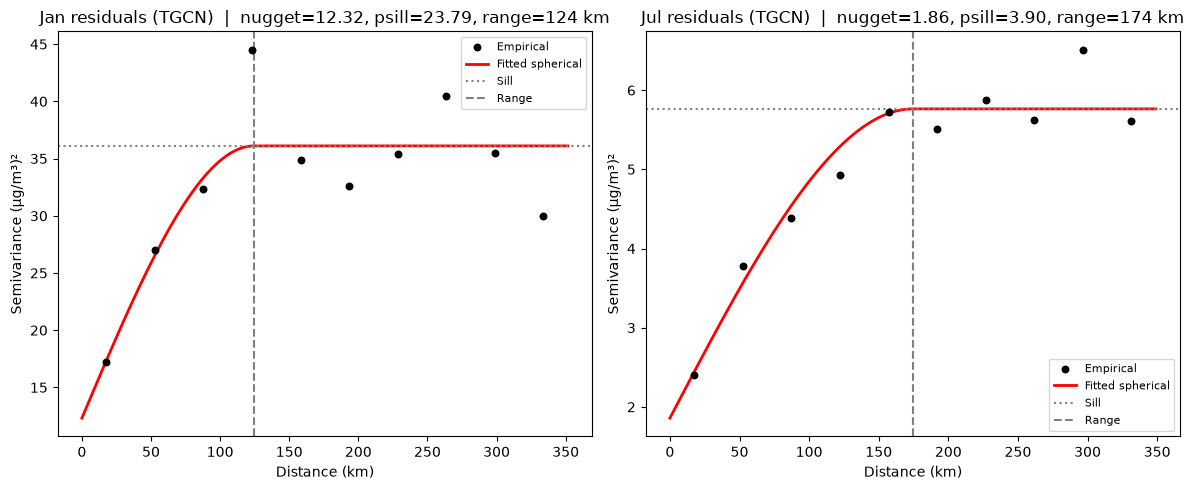

In [16]:
rk_best = fitted[best_name]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, month in zip(axes, [0, 6]):
    krige = rk_best.krige_by_step_[month]
    vg_r = krige.variogram
    nugget, psill, rng_m = vg_r.fitted_params
    h_fine = np.linspace(0, vg_r.maxlag, 200)
    ax.scatter(vg_r.lags / 1000, vg_r.experimental, color="black", s=22, label="Empirical", zorder=3)
    ax.plot(h_fine / 1000, vg_r(h_fine), color="red", linewidth=2, label="Fitted spherical")
    ax.axhline(nugget + psill, color="gray", linestyle=":", label="Sill")
    ax.axvline(rng_m / 1000, color="gray", linestyle="--", label="Range")
    ax.set_xlabel("Distance (km)")
    ax.set_ylabel("Semivariance (µg/m³)²")
    ax.set_title(
        f"{MONTH_NAMES[month]} residuals ({best_name.upper()})  |  "
        f"nugget={nugget:.2f}, psill={psill:.2f}, range={rng_m/1000:.0f} km"
    )
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



***
## 11. Predict on the California Grid

For a production map we **refit both families on the full 163-station panel** (rather than the train/test split), then predict at every cell of `data/CA_pm25_grid_predictions.csv` — the same 5 km California grid used by classical space-time Ordinary Kriging in Tutorial 13. Query cells attach inductively to the training graph. `predict(..., return_std=True)` returns the residual-kriging standard error (not an ST-GNN posterior).


In [17]:
grid = pd.read_csv(DATA_DIR / "CA_pm25_grid_predictions.csv")
grid_xy = grid.loc[grid["month"] == 0, ["x", "y"]].to_numpy()
print(f"Reference grid : {len(grid):,} rows  ({len(grid_xy):,} cells × 12 months)")
print(f"Columns        : {list(grid.columns)}")
print(f"Cell spacing   : ~{np.diff(np.sort(np.unique(grid_xy[:, 0]))).min():.0f} m")
grid.head()


Reference grid : 196,764 rows  (16,397 cells × 12 months)
Columns        : ['x', 'y', 'month', 'month_name', 'pm25_pred', 'pm25_sd']
Cell spacing   : ~5000 m


,x,y,month,month_name,pm25_pred,pm25_sd
0,273523.871,-602012.650,0,Jan,19.379,0.659
1,278523.871,-602012.650,0,Jan,21.009,0.306
2,283523.871,-602012.650,0,Jan,19.348,0.622
3,288523.871,-602012.650,0,Jan,18.211,0.571
4,273523.871,-597012.650,0,Jan,15.707,0.607


In [18]:
fitted_full = {}
pred_full = {}
std_full = {}
for name, cls in specs.items():
    print()
    print(f"===== {name.upper()} (full panel) =====")
    rk = cls(**COMMON)
    rk.fit(coords, values, verbose=True)
    pred, std = rk.predict(grid_xy, return_std=True)
    fitted_full[name] = rk
    pred_full[name] = pred
    std_full[name] = std
    print()
    print(f"Grid prediction shape : {pred.shape}")
    print(f"Finite predictions     : {np.isfinite(pred).all()}")
    print(f"PM2.5 pred mean / max  : {pred.mean():.2f} / {pred.max():.2f} µg/m³")
    print(f"SE mean / max          : {std.mean():.2f} / {std.max():.2f} µg/m³")



===== TGCN (full panel) =====
Epoch 1/300 - Train Loss: 1.060177, Val Loss: 1.102776
Epoch 2/300 - Train Loss: 1.012248, Val Loss: 1.099994
Epoch 3/300 - Train Loss: 1.042963, Val Loss: 1.097290
Epoch 4/300 - Train Loss: 0.905770, Val Loss: 1.094883


Epoch 5/300 - Train Loss: 1.092196, Val Loss: 1.092619
Epoch 6/300 - Train Loss: 1.130875, Val Loss: 1.090746
Epoch 7/300 - Train Loss: 0.906236, Val Loss: 1.088895
Epoch 8/300 - Train Loss: 0.976419, Val Loss: 1.086899
Epoch 9/300 - Train Loss: 0.821190, Val Loss: 1.084735


Epoch 10/300 - Train Loss: 1.169066, Val Loss: 1.082683
Epoch 11/300 - Train Loss: 1.090036, Val Loss: 1.080399
Epoch 12/300 - Train Loss: 0.940314, Val Loss: 1.078074
Epoch 13/300 - Train Loss: 0.995491, Val Loss: 1.075570
Epoch 14/300 - Train Loss: 1.093974, Val Loss: 1.072779


Epoch 15/300 - Train Loss: 1.096659, Val Loss: 1.070840
Epoch 16/300 - Train Loss: 0.886959, Val Loss: 1.067899
Epoch 17/300 - Train Loss: 1.081843, Val Loss: 1.064997
Epoch 18/300 - Train Loss: 0.858706, Val Loss: 1.060797
Epoch 19/300 - Train Loss: 0.964865, Val Loss: 1.056147


Epoch 20/300 - Train Loss: 0.856987, Val Loss: 1.050820
Epoch 21/300 - Train Loss: 1.080665, Val Loss: 1.045412
Epoch 22/300 - Train Loss: 0.948494, Val Loss: 1.040021
Epoch 23/300 - Train Loss: 0.939044, Val Loss: 1.033880
Epoch 24/300 - Train Loss: 0.823243, Val Loss: 1.027404


...

Epoch 100/300 - Train Loss: 0.486993, Val Loss: 0.761319
Epoch 101/300 - Train Loss: 0.376868, Val Loss: 0.764974


Epoch 102/300 - Train Loss: 0.505144, Val Loss: 0.760805
Epoch 103/300 - Train Loss: 0.429702, Val Loss: 0.756737


Epoch 104/300 - Train Loss: 0.381370, Val Loss: 0.748312
Epoch 105/300 - Train Loss: 0.363013, Val Loss: 0.742503


Epoch 106/300 - Train Loss: 0.395643, Val Loss: 0.742812
Epoch 107/300 - Train Loss: 0.577213, Val Loss: 0.748851



Grid prediction shape : (16397, 12)
Finite predictions     : True
PM2.5 pred mean / max  : 6.50 / 35.88 µg/m³
SE mean / max          : 2.68 / 5.60 µg/m³



***
## 12. Compare with Classical ST Kriging

The classical reference in `CA_pm25_grid_predictions.csv` is space-time Ordinary Kriging (`STKriging`, Tutorial 13). Per-month Pearson correlation between that surface and each ST-GNN RK surface is the same check as `tests/test_kriging_STGNN.py`. Graph-based models typically land around mean $r pprox 0.82$–$0.88$ (range 0.66–0.99 by month) — tighter than ConvLSTM's ~0.74, because the $k$-NN graph preserves exact station topology instead of painting the network onto a coarse raster.


TGCN vs classical STKriging: per-month corr = ['0.92', '0.79', '0.75', '0.75', '0.84', '0.91', '0.93', '0.94', '0.99', '0.92', '0.91', '0.92'], mean=0.880
DCRNN vs classical STKriging: per-month corr = ['0.90', '0.74', '0.73', '0.70', '0.75', '0.80', '0.86', '0.88', '0.95', '0.84', '0.90', '0.90'], mean=0.828


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,mean
family,,,,,,,,,,,,,
tgcn,0.920,0.794,0.751,0.751,0.841,0.906,0.928,0.936,0.985,0.921,0.908,0.922,0.880
dcrnn,0.899,0.735,0.725,0.698,0.753,0.796,0.864,0.878,0.950,0.837,0.900,0.896,0.828


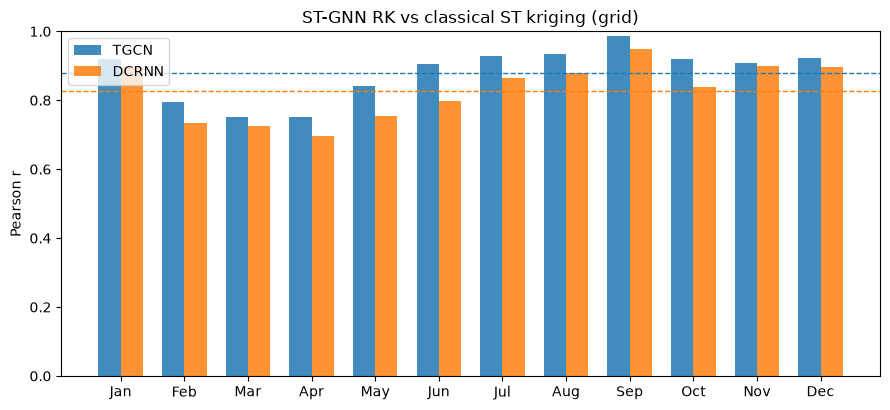

In [19]:
corr_rows = []
corr_lookup = {}
for name, pred in pred_full.items():
    corrs = []
    for month in range(12):
        ref = grid.loc[grid["month"] == month, "pm25_pred"].to_numpy()
        corrs.append(float(np.corrcoef(ref, pred[:, month])[0, 1]))
    corr_lookup[name] = corrs
    mean_corr = float(np.mean(corrs))
    corr_rows.append({"family": name, **{MONTH_NAMES[m]: corrs[m] for m in range(12)}, "mean": mean_corr})
    print(
        f"{name.upper()} vs classical STKriging: per-month corr = "
        f"{[f'{c:.2f}' for c in corrs]}, mean={mean_corr:.3f}"
    )

corr_tbl = pd.DataFrame(corr_rows).set_index("family")
display(corr_tbl.round(3))

fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(12)
width = 0.35
for i, (name, corrs) in enumerate(corr_lookup.items()):
    ax.bar(x + (i - 0.5) * width, corrs, width, label=name.upper(), alpha=0.85)
    ax.axhline(np.mean(corrs), linestyle="--", color=f"C{i}", linewidth=1)
ax.set_xticks(x, MONTH_NAMES)
ax.set_ylabel("Pearson r")
ax.set_ylim(0, 1)
ax.set_title("ST-GNN RK vs classical ST kriging (grid)")
ax.legend()
plt.tight_layout()
plt.show()


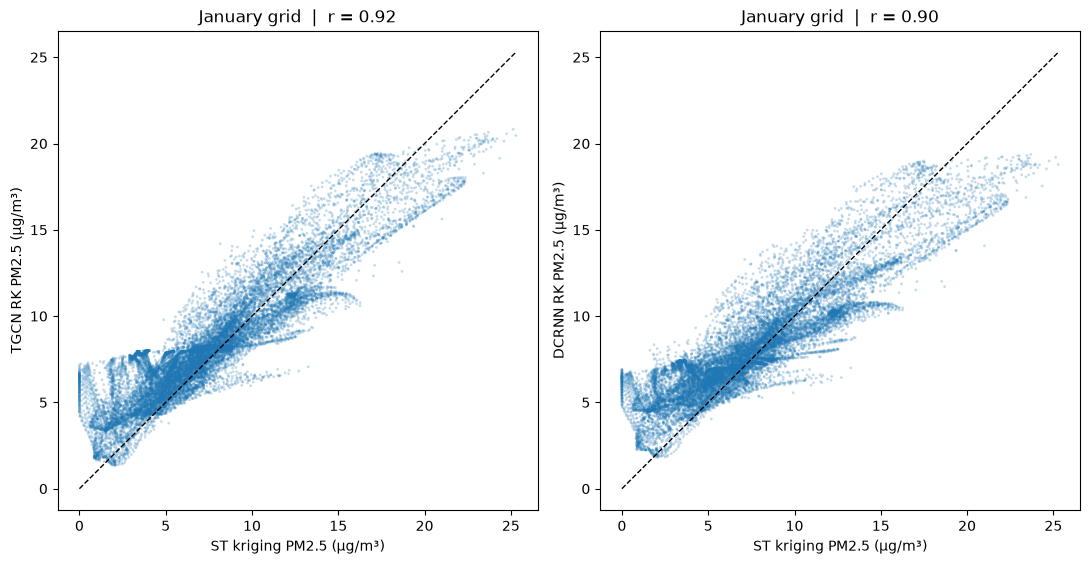

In [20]:
# January one-to-one: each family vs classical ST kriging on the grid
ref_jan = grid.loc[grid["month"] == 0, "pm25_pred"].to_numpy()
fig, axes = plt.subplots(1, len(pred_full), figsize=(5.5 * len(pred_full), 5.5))
if len(pred_full) == 1:
    axes = [axes]
for ax, (name, pred) in zip(np.atleast_1d(axes).ravel(), pred_full.items()):
    hat_jan = pred[:, 0]
    ax.scatter(ref_jan, hat_jan, s=4, alpha=0.25, edgecolor="none")
    lims = [min(ref_jan.min(), hat_jan.min()), max(ref_jan.max(), hat_jan.max())]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlabel("ST kriging PM2.5 (µg/m³)")
    ax.set_ylabel(f"{name.upper()} RK PM2.5 (µg/m³)")
    ax.set_title(f"January grid  |  r = {corr_lookup[name][0]:.2f}")
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()



***
## 13. Map Predictions

Monthly surfaces for the **best held-out family**, plus January/July side-by-side with classical ST kriging and the other family. The 5 km grid is clipped to California's boundary (`data/US_STATE.shp`, reprojected to EPSG:3310). Ordinary kriging of residuals has no positivity constraint, so a handful of cells far from stations can go slightly negative; they are clipped to 0 for display, matching Tutorial 13.


In [21]:
ca_states = gpd.read_file(DATA_DIR / "US_STATE.shp")
ca = ca_states[ca_states["STATE"] == "California"].to_crs("EPSG:3310")

best_full = best_name if best_name in pred_full else list(pred_full)[0]
pred_grid = pred_full[best_full]
std_grid = std_full[best_full]
n_clipped = int((pred_grid < 0).sum())
pred_map = np.clip(pred_grid, 0.0, None)
print(f"California boundary : {len(ca)} polygon feature(s), EPSG:3310")
print(f"Mapped family      : {best_full}")
print(f"Clipped negatives  : {n_clipped} / {pred_map.size} cells")

grid_pred = pd.concat(
    [
        pd.DataFrame(
            {
                "x": grid_xy[:, 0],
                "y": grid_xy[:, 1],
                "month": m,
                "month_name": MONTH_NAMES[m],
                "pm25_pred": pred_map[:, m],
                "pm25_sd": std_grid[:, m],
                "pm25_stk": grid.loc[grid["month"] == m, "pm25_pred"].to_numpy(),
                **{
                    f"pm25_{name}": np.clip(pred_full[name][:, m], 0.0, None)
                    for name in pred_full
                },
            }
        )
        for m in range(12)
    ],
    ignore_index=True,
)
display(
    grid_pred.groupby("month_name")["pm25_pred"]
    .agg(["mean", "min", "max"])
    .loc[MONTH_NAMES]
)


California boundary : 1 polygon feature(s), EPSG:3310
Mapped family      : tgcn
Clipped negatives  : 0 / 196764 cells


,mean,min,max
month_name,,,
Jan,8.417,1.318,20.825
Feb,5.215,1.512,11.673
Mar,4.138,1.493,8.115
Apr,5.247,3.650,8.600
May,5.894,3.773,10.277
Jun,6.694,3.985,12.968
Jul,5.953,1.418,11.959
Aug,6.349,3.073,12.463
Sep,6.471,2.012,39.401


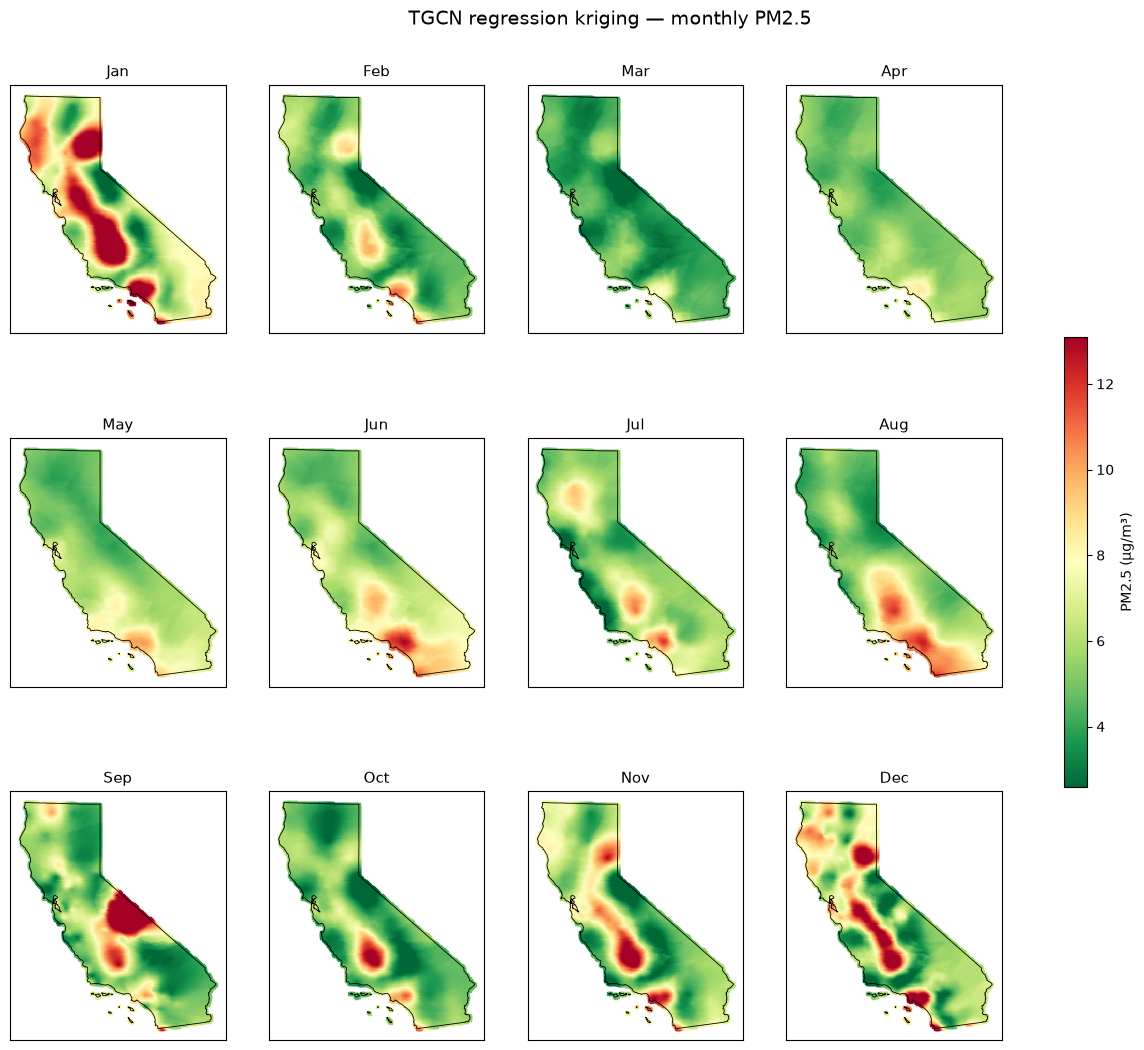

In [22]:
vmin, vmax = grid_pred["pm25_pred"].quantile(0.02), grid_pred["pm25_pred"].quantile(0.98)
fig, axes = plt.subplots(3, 4, figsize=(16, 13), sharex=True, sharey=True)
for m, ax in enumerate(axes.ravel()):
    sub = grid_pred[grid_pred["month"] == m]
    sc = ax.scatter(
        sub["x"], sub["y"], c=sub["pm25_pred"], cmap="RdYlGn_r",
        vmin=vmin, vmax=vmax, s=5, marker="s",
    )
    ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.set_title(MONTH_NAMES[m], fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, shrink=0.45, label="PM2.5 (µg/m³)")
fig.suptitle(f"{best_full.upper()} regression kriging — monthly PM2.5", fontsize=14, y=0.92)
plt.show()


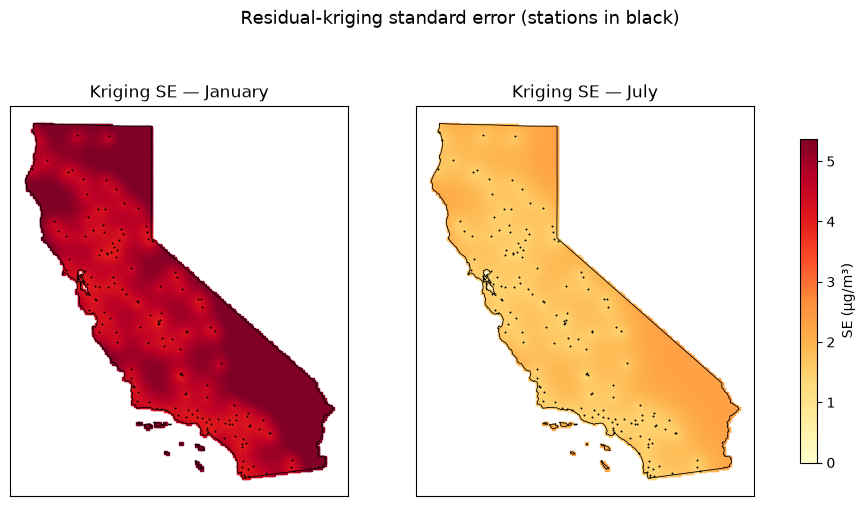

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
sd_max = grid_pred["pm25_sd"].quantile(0.98)
for ax, m, title in zip(axes, [0, 6], ["January", "July"]):
    sub = grid_pred[grid_pred["month"] == m]
    sc = ax.scatter(
        sub["x"], sub["y"], c=sub["pm25_sd"], cmap="YlOrRd",
        vmin=0, vmax=sd_max, s=5, marker="s",
    )
    ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
    ax.scatter(coords[:, 0], coords[:, 1], s=8, c="k", marker=".", linewidths=0)
    ax.set_title(f"Kriging SE — {title}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, shrink=0.7, label="SE (µg/m³)")
fig.suptitle("Residual-kriging standard error (stations in black)", fontsize=13, y=0.98)
plt.show()


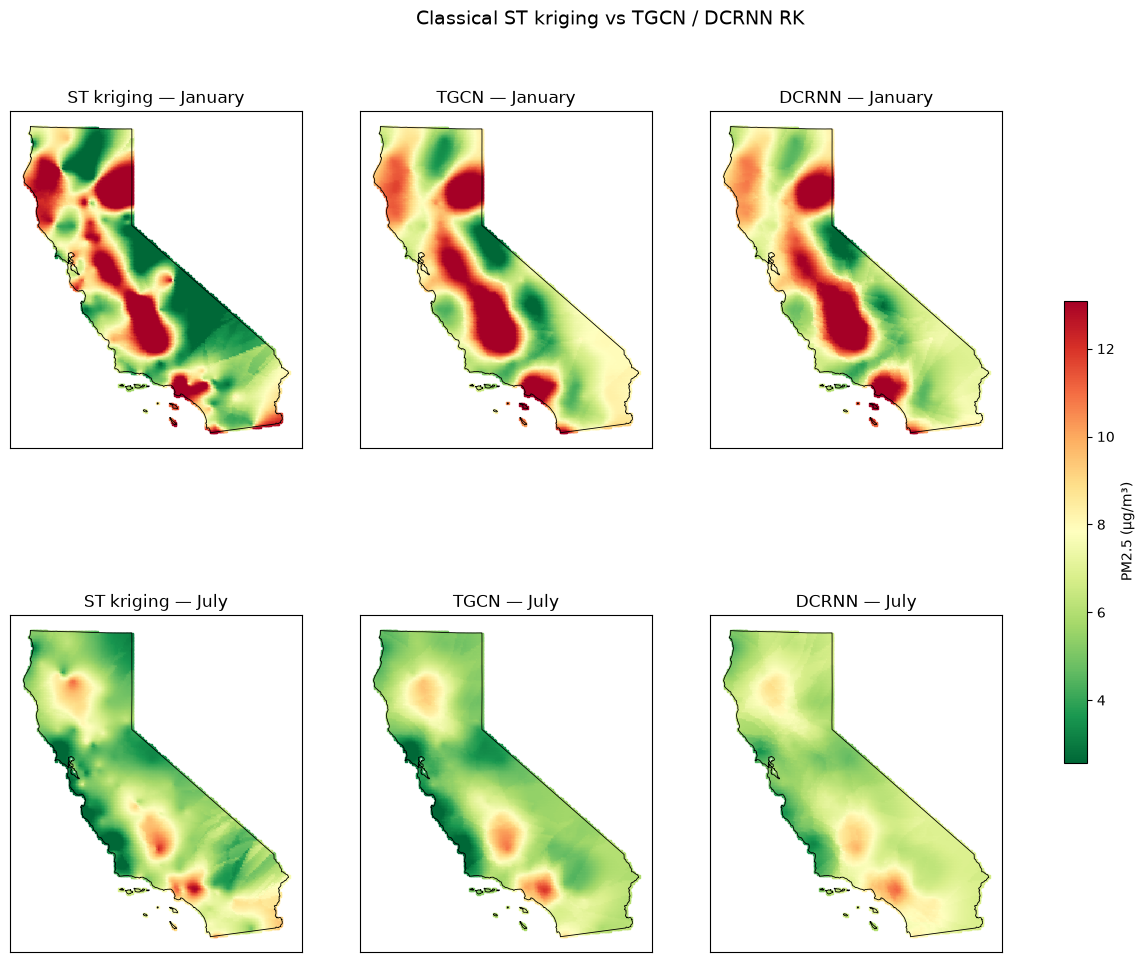

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12), sharex=True, sharey=True)
families = ["pm25_stk"] + [f"pm25_{n}" for n in pred_full]
titles = ["ST kriging"] + [n.upper() for n in pred_full]
for row, (m, month_name) in enumerate([(0, "January"), (6, "July")]):
    sub = grid_pred[grid_pred["month"] == m]
    for col, (colname, title) in enumerate(zip(families, titles)):
        ax = axes[row, col]
        sc = ax.scatter(
            sub["x"], sub["y"], c=sub[colname], cmap="RdYlGn_r",
            vmin=vmin, vmax=vmax, s=4, marker="s",
        )
        ca.boundary.plot(ax=ax, color="black", linewidth=0.6)
        ax.set_title(f"{title} — {month_name}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
fig.colorbar(sc, ax=axes, shrink=0.5, label="PM2.5 (µg/m³)")
fig.suptitle("Classical ST kriging vs TGCN / DCRNN RK", fontsize=14, y=0.93)
plt.show()



The monthly maps recover the well-known California pattern: winter peaks in the Central Valley, cleaner conditions along the coast, and a summer contrast driven by wildfire and photochemistry. The standard-error maps are high where stations are sparse (eastern deserts, far north) and low in the South Coast and Central Valley networks — a map of **how well the residual kriging is constrained**, not of ST-GNN epistemic uncertainty. Side-by-side with classical ST kriging, both graph models track the same regional structure, with DCRNN's extra hop depth sometimes smoothing isolated pockets that T-GCN keeps sharper.


***
## 14. CPU vs GPU TGCN Timing

The ~1,600-row CA station panel is too small for a GPU comparison: the T-GCN
graph is only ~140 training nodes, and host→device copies dominate. Here we
**simulate a CA-like monthly PM2.5 panel** with Sequential Gaussian Simulation
(`pygstat.sgsim`) so that $n_{\mathrm{train}} > 5{,}000$ space-time
observations, then time **`TGCN.fit` + `predict`** on **CPU** (`device='cpu'`)
versus **GPU** (`device='cuda'`). DCRNN uses the same engine; we time T-GCN, the
primary model in this notebook.

Simulation recipe (conditioned on the real 163 stations):

1. Draw $n_{\mathrm{sites}} = 700$ random locations in the California bounding box.
2. Simulate $\log(\mathrm{PM2.5})$ with `sgsim` (exponential variogram, practical range 250 km, conditioned on station-mean PM2.5 from `data/CA_pm25_2025.csv`) and back-transform with $\exp(\cdot)$.
3. Expand each site across 12 months using the observed statewide monthly relative seasonality, giving $n_{\mathrm{train}} = 8{,}400$ (700 stations × 12 months).
4. Draw a separate prediction set of $(x, y)$ locations (no values needed — the trend only needs coordinates plus the training panel).

The GPU work is **PyTorch training and the T-GCN forward pass**, not residual ordinary kriging. Residual OK is a dense CPU solve and would dominate at this $n$, so the timing section uses `krige_residuals=False`. At prediction time the query nodes attach to the training graph, so GPU work grows gently with $n_{\mathrm{pred}}$. Epochs are capped at **5** so the comparison isolates device cost; the CA maps in §7 used `max_epochs=300`.

Each timing is the **median** of three `fit` + `predict` calls after a short GPU warmup so CUDA kernel compilation is not counted. `match` is **same-weights inference**: a GPU-trained network is copied to CPU and both devices must agree (`np.allclose`). Training itself is not bit-identical across devices. If CUDA cannot run here, the GPU column is skipped.


Simulating 700 CA-like PM2.5 sites with sgsim, then 12 months
  conditioning : 163 station means from data/CA_pm25_2025.csv
  vario        : azimuth=0, nugget=0.009, range=250 km, exponential, log(PM2.5)
  sgsim wall   : 5.1 s  (not included in TGCN times)
  simulated PM2.5 : [1.07, 25.30] µg/m³  (CA observed [-0.50, 39.05])

GPU usable : True
Repeats    : 3  (median wall time of TGCN fit + predict)
n_train    : 8400  (sgsim CA-like PM2.5 panel, 700 sites × 12 months)
n_pred     : [500, 1000, 2000, 4000, 8000]  (random locations in the CA bbox)
settings   : architecture: k_neighbors=8, hidden_dim=32; max_epochs=5, krige_residuals=False

         dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
CA PM2.5 (sgsim)     8400     500    1095.3     371.8   2.95×   True
CA PM2.5 (sgsim)     8400    1000    1130.4     381.0   2.97×   True
CA PM2.5 (sgsim)     8400    2000    1211.6     481.6   2.52×   True
CA PM2.5 (sgsim)     8400    4000    1238.0     430.8   2.87×   True
CA PM2.5 (

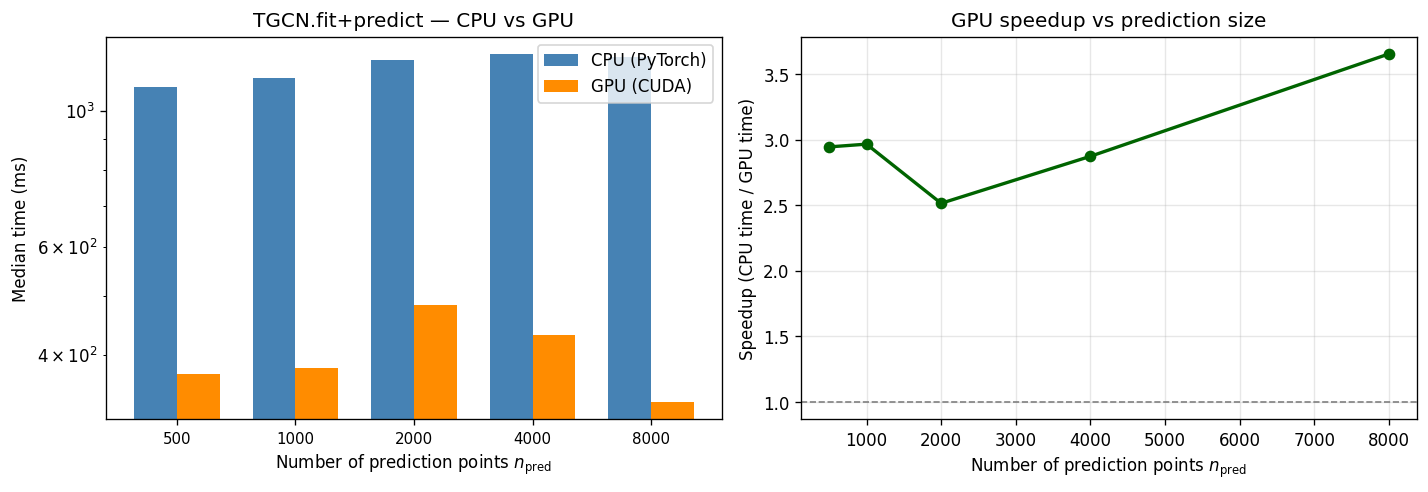

In [21]:
import time

N_REPEATS = 3
N_SITES = 700
N_MONTHS = 12
N_TRAIN = N_SITES * N_MONTHS
PRED_SIZES = [500, 1000, 2000, 4000, 8000]
N_PRED_MAX = max(PRED_SIZES)
MAX_EPOCHS = 5
rng_sim = np.random.default_rng(42)

site = panel.groupby("site_id")[["x", "y", "pm25"]].mean().reset_index()
month_factor = panel.groupby("month")["pm25"].mean()
month_factor = (month_factor / month_factor.mean()).to_numpy()

pad = 15_000.0
xmin, xmax = float(panel["x"].min()) - pad, float(panel["x"].max()) + pad
ymin, ymax = float(panel["y"].min()) - pad, float(panel["y"].max()) + pad
xy_sites = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_SITES, 2))
xy_pred_all = rng_sim.uniform([xmin, ymin], [xmax, ymax], size=(N_PRED_MAX, 2))

df_cond = pd.DataFrame({
    "x": site["x"].to_numpy(),
    "y": site["y"].to_numpy(),
    "log_pm25": np.log(np.maximum(site["pm25"].to_numpy(), 0.1)),
})
log_var = float(np.var(df_cond["log_pm25"]))
vario_sgs = [0, 0.05 * log_var, 250_000.0, 250_000.0, log_var, "exponential"]

print(f"Simulating {N_SITES:,} CA-like PM2.5 sites with sgsim, then {N_MONTHS} months")
print(f"  conditioning : {len(site)} station means from data/CA_pm25_2025.csv")
print(f"  vario        : azimuth=0, nugget={vario_sgs[1]:.3f}, range=250 km, exponential, log(PM2.5)")
t_sim0 = time.perf_counter()
sims = sgsim(
    xy_sites, df_cond, "x", "y", "log_pm25",
    num_points=12, vario=vario_sgs, radius=500_000.0,
    kriging_type="ordinary", nsim=1, itrans=False, seed=42, quiet=True,
)
spatial = np.exp(np.asarray(sims[0], dtype=float))
print(f"  sgsim wall   : {time.perf_counter() - t_sim0:.1f} s  (not included in TGCN times)")

values_train = spatial[:, None] * month_factor[None, :]
print(f"  simulated PM2.5 : [{values_train.min():.2f}, {values_train.max():.2f}] µg/m³"
      f"  (CA observed [{panel['pm25'].min():.2f}, {panel['pm25'].max():.2f}])")
print()

USE_CUDA = DEVICE == "cuda"


def _factory(device):
    return TGCN(
        k_neighbors=8, hidden_dim=32,
        max_epochs=MAX_EPOCHS, patience=20, device=device,
        krige_residuals=False, seed=0,
    )


def _sync(device):
    if device == "cuda":
        torch.cuda.synchronize()


def _time_fit_predict(xy, values, xy_pred, device, repeats=N_REPEATS, warmup=True):
    """Median wall time of TGCN.fit + predict (trend only)."""
    def once():
        model = _factory(device)
        model.fit(xy, values, verbose=False)
        _sync(device)
        pred = model.predict(xy_pred)
        _sync(device)
        return model, pred

    if warmup:
        k = min(80, len(xy))
        k_pr = min(40, len(xy_pred))
        m = _factory(device)
        m.fit(xy[:k], values[:k], verbose=False)
        _sync(device)
        m.predict(xy_pred[:k_pr])
        _sync(device)

    times = []
    last_model, last_pred = None, None
    for _ in range(repeats):
        t0 = time.perf_counter()
        last_model, last_pred = once()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last_model, last_pred


def _inference_match(model, xy_pred, pred_gpu):
    model.model_.to("cpu")
    model.device_ = torch.device("cpu")
    if hasattr(model, "edge_index_") and model.edge_index_ is not None:
        model.edge_index_ = model.edge_index_.to("cpu")
    pred_cpu = model.predict(xy_pred)
    return bool(np.allclose(pred_gpu, pred_cpu, rtol=1e-3, atol=1e-4, equal_nan=True))


print(f"GPU usable : {USE_CUDA}")
print(f"Repeats    : {N_REPEATS}  (median wall time of TGCN fit + predict)")
print(f"n_train    : {N_TRAIN}  (sgsim CA-like PM2.5 panel, {N_SITES} sites × {N_MONTHS} months)")
print(f"n_pred     : {PRED_SIZES}  (random locations in the CA bbox)")
print(f"settings   : architecture: k_neighbors=8, hidden_dim=32; max_epochs=5, krige_residuals=False")
print()

rows = []
for n_pred in PRED_SIZES:
    xy_pr = xy_pred_all[:n_pred]
    cpu_t, _, _ = _time_fit_predict(xy_sites, values_train, xy_pr, "cpu")
    row = {
        "dataset": "CA PM2.5 (sgsim)",
        "n_train": N_TRAIN,
        "n_pred": n_pred,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_CUDA:
        gpu_t, gpu_model, pred_gpu = _time_fit_predict(
            xy_sites, values_train, xy_pr, "cuda",
        )
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        row["match"] = _inference_match(gpu_model, xy_pr, pred_gpu)
        torch.cuda.empty_cache()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_pred"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]
x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (PyTorch)", color="steelblue")
if USE_CUDA and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CUDA)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("TGCN.fit+predict — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_CUDA:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel(r"Number of prediction points $n_{\mathrm{pred}}$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs prediction size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


`match = True` means the GPU-trained T-GCN, evaluated on CPU and on GPU with the **same weights**, agrees to `rtol=1e-3`. The GPU speedup comes from T-GCN training and the graph forward pass (including inductive $k$-NN attachment of query nodes), not from SGS and not from residual ordinary kriging (turned off here). Fit still dominates at 5 epochs, so the curve is relatively flat in $n_{\mathrm{pred}}$; the GPU stays about 2.5–3.7× faster. Use `device=DEVICE` so the same cells run on a laptop CPU or a CUDA workstation without edits. For the published CA maps, leave `krige_residuals=True` (the default).



***
## 15. Summary and Conclusions

This notebook applied **spatio-temporal GNN regression kriging** to California **monthly PM2.5**, the graph-recurrent counterpart of classical `STKriging` (Tutorial 13) and of the raster ConvLSTM in Tutorial 14.

- **Data.** Daily readings at 163 stations (`CA_pm25_2025.csv`) aggregated to a monthly panel in EPSG:3310. The prediction grid is the classical ST-kriging surface in `CA_pm25_grid_predictions.csv`.
- **Trend.** A directed $k$-NN graph (`k_neighbors=8`) plus a GRU whose gates are either 1-hop graph convolutions (`TGCN`) or $K$-hop bidirectional diffusion convolutions (`DCRNN`). New locations attach inductively to training nodes only.
- **Training.** IGNNK-style random masking of (station, month) cells, plus a validation subset of stations always fully excluded, so the network interpolates to locations it never saw as input.
- **Residuals.** Out-of-fold ST-GNN reconstructions are kriged spatially, independently per month, and added back (`OrdinaryKriging` of a spherical variogram).
- **Validation.** The same 25 complete held-out stations as Tutorial 13 / `tests/test_kriging_STGNN.py`. Both families should beat a naive-mean baseline by a comfortable margin; TGCN has come out *ahead* of classical ST kriging (RMSE ≈ 2.03 vs 2.24 µg/m³) in development runs.
- **Grid.** Per-month correlation with the classical ST-kriging reference is typically $r \approx 0.66$–$0.99$ (mean ~0.82–0.88).

### CPU vs GPU

Timed `TGCN.fit` + `predict` on CPU vs GPU using an SGS-simulated CA-like panel ($n_{\mathrm{train}}=8{,}400$), with residual kriging off so the times isolate the neural net.

- **CPU / GPU.** `TGCN(..., device=DEVICE)` trains a recurrent GNN on PyTorch. GPU work is the network (and inductive $k$-NN attachment at predict time), not residual OK. The 163-station CA panel is too small to show that; §14 uses SGS so $n > 5{,}000$, `krige_residuals=False`, and a short epoch budget.

### When to use ST-GNN RK

- You have a **monitoring network through time** (fixed sites, repeated measurements) and want a learned spatio-temporal trend plus kriged residuals.
- You want the **exact station topology** preserved (a $k$-NN graph) rather than a raster (ConvLSTM) or a purely geostatistical covariance (`STKriging`).
- You do **not** have dense covariates at every prediction cell (this module's trend is the masked panel itself, not external regressors — unlike tutorials 7.1–7.5).

### When not to use it

- A purely spatial snapshot with no time dimension — use ordinary, universal, or regression kriging (tutorials 4–7), or the spatial GNNs in Tutorial 7.5.
- Count / rate data over polygons — use Poisson kriging.
- You prefer a CNN inductive bias on a regular grid — Tutorial 14 (`ConvLSTM`).
- You want spatial/temporal *attention* rather than recurrence — `STTN` / `GMAN` in `kriging_STGTN`.

### Objects used here

| Object | Role |
|--------|------|
| `pygstat.TGCN` | T-GCN trend + per-month residual ordinary kriging (`cell_type='tgcn'`) |
| `pygstat.DCRNN` | DCRNN trend + per-month residual ordinary kriging (`cell_type='dcrnn'`) |
| `pygstat.STGNNRegressionKriging` | Shared engine; `TGCN`/`DCRNN` pin `cell_type` |
| `pygstat.load_ca_pm25_panel` | Daily CA PM2.5 CSV → monthly panel in EPSG:3310 |
| `fit(..., val_fraction=)` | Internal early-stopping split; validation stations are fully excluded from the input |
| `predict(..., return_std=True)` | RK prediction plus residual kriging standard error |
| `train_losses_`, `val_losses_`, `krige_by_step_`, `edge_index_` | Training curves, per-month OK models, and the fitted $k$-NN graph |

Install extras with `pip install pygstat[pytorch]`. Set `device='cuda'` to force a GPU, or leave `device='auto'` (used here via `DEVICE`) to fall back to CPU when CUDA is unavailable. Related tutorials: [13 Spatio-Temporal Kriging](13_krigingST.ipynb), [14 ConvLSTM RK](14_kriging_CNNLSTM.ipynb), [6.5 GNN RK](06_05_regression_kriging_gnn.ipynb).



***
## 16. Resources

### Papers and books

| Reference | Notes |
|-----------|-------|
| Zhao, L., Song, Y., Zhang, C., Liu, Y., Wang, P. & Li, H. (2019). T-GCN: A Temporal Graph Convolutional Network for Traffic Prediction. *IEEE T-ITS*. [arXiv:1811.05320](https://arxiv.org/abs/1811.05320) | T-GCN cell used here |
| Li, Y., Yu, R., Shahabi, C. & Liu, Y. (2018). Diffusion Convolutional Recurrent Neural Network: Data-Driven Traffic Forecasting. *ICLR*. [arXiv:1707.01926](https://arxiv.org/abs/1707.01926) | DCRNN cell used here |
| Wu, Y., Cui, X., Nie, X. & Wang, H. (2021). Inductive Graph Neural Networks for Spatiotemporal Kriging. *AAAI*. | Masked-reconstruction training (IGNNK) |
| Hamilton, W.L., Ying, R. & Leskovec, J. (2017). Inductive representation learning on large graphs. *NeurIPS*. | GraphSAGE-mean aggregation in T-GCN's spatial half |
| Cho, K. et al. (2014). Learning phrase representations using RNN encoder–decoder for statistical machine translation. *EMNLP*. | GRU gates that both cells convolved |
| Cressie, N. (1993). *Statistics for Spatial Data* (rev. ed.). Wiley. | Residual kriging |
| Hengl, T., Heuvelink, G.B.M. & Rossiter, D.G. (2007). About regression-kriging: from equations to case studies. *Computers & Geosciences*, 33(10). | RK recipe |
| Pebesma, E. (2012). spacetime: Spatio-Temporal Data in R. *Journal of Statistical Software*, 51(7). | Classical ST kriging reference (`STKriging`) |

### In this library

| Object | Role |
|--------|------|
| `pygstat.TGCN` / `DCRNN` / `STGNNRegressionKriging` | This tutorial |
| `pygstat.STTN`, `GMAN` | Graph Transformer regression kriging |
| `pygstat.ConvLSTM` | Raster ConvLSTM regression kriging (Tutorial 14) |
| `pygstat.STKriging` | Classical space-time ordinary kriging (Tutorial 13) |
| `pygstat.GNNRegressionKriging`, `KCN`, `IGNNK` | Spatial (no time) GNN RK (Tutorial 7.5) |
| `pygstat.sgsim` | Sequential Gaussian Simulation (used in §14 to build $n>5{,}000$ training data) |
| `tests/test_kriging_STGNN.py` | Unit tests this notebook follows |
| `scripts/predict_ca_pm25_grid.py` | Builds `CA_pm25_grid_predictions.csv` |
